In [4]:
import pandas as pd
from sklearn.datasets import load_iris
d = load_iris()

In [5]:
dir(d)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [6]:
df = pd.DataFrame(d.data, columns=d.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
df['target'] = d.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
df[0:12]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [11]:
X = df.drop('target',axis='columns')
y = df.target

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [16]:
from sklearn.ensemble import RandomForestClassifier
m = RandomForestClassifier(n_estimators=10)
m.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10)

In [18]:
m.score(X_test, y_test)

0.9333333333333333

In [19]:
y_pred = m.predict(X_test)

In [20]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[10,  0,  0],
       [ 0, 11,  0],
       [ 0,  2,  7]])

Text(95.72222222222221, 0.5, 'Truth')

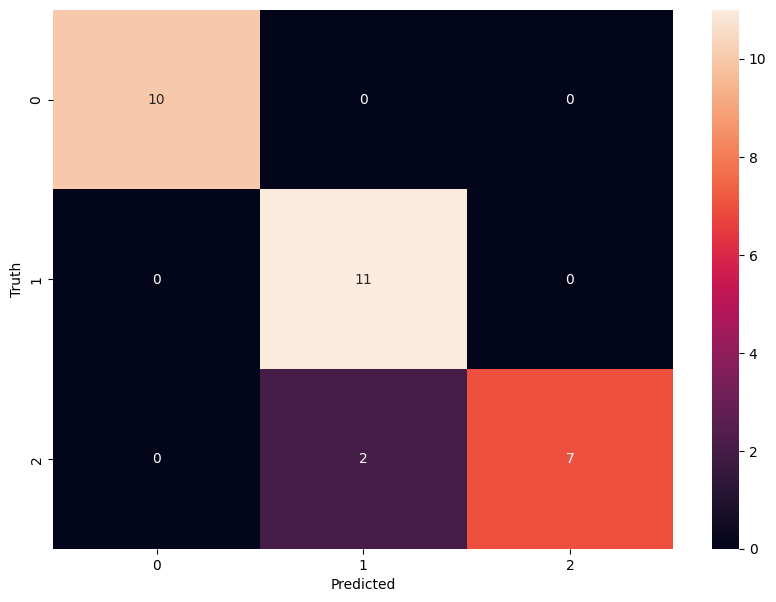

In [21]:
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot = True)
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [23]:
scores = []
for i in [5,10,20,30,50,100]:
    model = RandomForestClassifier(
        n_estimators=i,
        random_state=42
    )
    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)
    print("Trees:", i, " Score:", score)
    scores.append(score)

Trees: 5  Score: 0.9666666666666667
Trees: 10  Score: 1.0
Trees: 20  Score: 0.9333333333333333
Trees: 30  Score: 0.9666666666666667
Trees: 50  Score: 0.9666666666666667
Trees: 100  Score: 0.9666666666666667
